Part 1: Data Preprocessing & Feature Engineering

In [1]:
# Data Ingestion & Cleaning

import os
import requests
from urllib.parse import urlparse
import polars as pl
import pandas as pd

os.makedirs('data/raw', exist_ok=True)
files_to_download = {
    "Yellow Taxi Trip Data": "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet",
    "Taxi Zone Lookup Table": "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
}

for file_name_base, url in files_to_download.items():
    response = requests.get(url)
    parsed_url = urlparse(url)
    original_extension = os.path.splitext(parsed_url.path)[1]
    local_file_name = f'data/raw/{file_name_base}{original_extension}'

    with open(local_file_name, 'wb') as f:
        f.write(response.content)
    print(f"{file_name_base} downloaded successfully to {local_file_name}.")


taxi_file = 'data/raw/Yellow Taxi Trip Data.parquet'
df = pl.read_parquet(taxi_file)
print(f'Yellow taxi data starts with {len(df):,} rows')

# Drop rows with nulls in critical columns
critical_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'fare_amount', 'tip_amount', 'payment_type']
before = len(df)
df = df.drop_nulls(subset=critical_cols)
after = len(df)
print(f'{after:,} rows remain after removing {before - after:,} null rows')

# Remove trips with invalid distance or fare
before = len(df)
df = df.filter((pl.col('trip_distance') > 0) &
               (pl.col('fare_amount') > 0) &
               (pl.col('fare_amount') <= 500))
after = len(df)
print(f'{after:,} rows remain after removing {before - after:,} invalid trips')

# Remove rows where dropoff is before pickup
before = len(df)
df = df.filter(pl.col('tpep_dropoff_datetime') >= pl.col('tpep_pickup_datetime'))
after = len(df)
print(f'{after:,} rows remain after removing {before - after:,} dropoff errors')

# Filter for credit card payments only
before = len(df)
df = df.filter(pl.col('payment_type') == 1)
after = len(df)
print(f'{after:,} rows remain after filtering for credit card payments (removed {before - after:,})')

rows_removed = len(pl.read_parquet(taxi_file)) - len(df)
print(f'{rows_removed:,} rows removed overall')


df = df.to_pandas()

zones = pd.read_csv('data/raw/Taxi Zone Lookup Table.csv')
df = df.merge(zones[['LocationID', 'Borough']], left_on='PULocationID', right_on='LocationID', how='left')

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

print("Data ready for Part 1: Feature Engineering")
print(f"Final dataset shape: {df.shape}")


Yellow Taxi Trip Data downloaded successfully to data/raw/Yellow Taxi Trip Data.parquet.
Taxi Zone Lookup Table downloaded successfully to data/raw/Taxi Zone Lookup Table.csv.
Yellow taxi data starts with 2,964,624 rows
2,964,624 rows remain after removing 0 null rows
2,869,684 rows remain after removing 94,940 invalid trips
2,869,628 rows remain after removing 56 dropoff errors
2,298,380 rows remain after filtering for credit card payments (removed 571,248)
666,244 rows removed overall
Data ready for Part 1: Feature Engineering
Final dataset shape: (2298380, 21)


In [2]:
# Part 1.1: Feature Engineering
import numpy as np

# Temporal features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday
df['is_weekend'] = df['pickup_day_of_week'].isin([5, 6]).astype(int)

# Trip features
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['trip_speed_mph'] = df['trip_distance'] / (df['trip_duration_minutes'] / 60).replace(0, np.nan)
df['log_trip_distance'] = np.log1p(df['trip_distance'])

# Fare features
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance'].replace(0, np.nan)
df['fare_per_minute'] = df['fare_amount'] / df['trip_duration_minutes'].replace(0, np.nan)

# Zone features
zones = pd.read_csv('data/raw/Taxi Zone Lookup Table.csv')
borough_map = zones.set_index('LocationID')['Borough'].to_dict()

df['pickup_borough'] = df['PULocationID'].map(borough_map)
df['dropoff_borough'] = df['DOLocationID'].map(borough_map)

df = pd.get_dummies(df, columns=['pickup_borough', 'dropoff_borough'], prefix=['PU', 'DO'])

print("Feature engineering complete")
print("Feature columns created:", [col for col in df.columns if col not in ['tpep_pickup_datetime','tpep_dropoff_datetime']][:15], "...")


Feature engineering complete
Feature columns created: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount'] ...


In [3]:
# Part 1.2: Target Variable Creation
#Regression
df['tip_amount'] = df['tip_amount']

# Classification
df['high_tip'] = (df['tip_amount'] > 0.2 * df['fare_amount']).astype(int)

print("Target variables created")
print("Tip amount sample:", df['tip_amount'].head())
print("High tip distribution:", df['high_tip'].value_counts(normalize=True))


Target variables created
Tip amount sample: 0    3.75
1    3.00
2    2.00
3    3.20
4    6.90
Name: tip_amount, dtype: float64
High tip distribution: high_tip
1    0.759324
0    0.240676
Name: proportion, dtype: float64


In [4]:
# Part 1.3: Data Splitting & Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

numeric_features = [
    'pickup_hour', 'pickup_day_of_week', 'trip_duration_minutes',
    'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']

X = df[numeric_features + [col for col in df.columns if col.startswith('PU_') or col.startswith('DO_')]]
y_regression = df['tip_amount']
y_classification = df['high_tip']

# Split
X_train, X_temp, y_regression_train, y_regression_temp, y_classification_train, y_classification_temp = train_test_split(
    X, y_regression, y_classification, test_size=0.30, random_state=42, stratify=y_classification)

X_val, X_test, y_regression_val, y_regression_test, y_classification_val, y_classification_test = train_test_split(
    X_temp, y_regression_temp, y_classification_temp, test_size=0.50, random_state=42, stratify=y_classification_temp)

# Drop rows with NaNs in each split
def drop_nan_rows(X, y_regression, y_classification):
    mask = ~X.isna().any(axis=1)
    return X[mask], y_regression[mask], y_classification[mask]

X_train, y_regression_train, y_classification_train = drop_nan_rows(X_train, y_regression_train, y_classification_train)
X_val, y_regression_val, y_classification_val = drop_nan_rows(X_val, y_regression_val, y_classification_val)
X_test, y_regression_test, y_classification_test = drop_nan_rows(X_test, y_regression_test, y_classification_test)

# Scale
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Data splitting and scaling complete (NaN rows dropped)")
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
print("High tip distribution (train):", y_classification_train.value_counts(normalize=True))
print("High tip distribution (val):", y_classification_val.value_counts(normalize=True))
print("High tip distribution (test):", y_classification_test.value_counts(normalize=True))

# Print summary
feature_summary = pd.DataFrame({
    "Feature": X_train.columns,
    "Type": ["numeric" if f in numeric_features else "categorical" for f in X_train.columns]})
print(feature_summary.head(15))


Data splitting and scaling complete (NaN rows dropped)
Training set: (1608846, 21), Validation set: (344749, 21), Test set: (344752, 21)
High tip distribution (train): high_tip
1    0.759326
0    0.240674
Name: proportion, dtype: float64
High tip distribution (val): high_tip
1    0.759329
0    0.240671
Name: proportion, dtype: float64
High tip distribution (test): high_tip
1    0.759328
0    0.240672
Name: proportion, dtype: float64
                  Feature         Type
0             pickup_hour      numeric
1      pickup_day_of_week      numeric
2   trip_duration_minutes      numeric
3          trip_speed_mph      numeric
4       log_trip_distance      numeric
5           fare_per_mile      numeric
6         fare_per_minute      numeric
7                PU_Bronx  categorical
8             PU_Brooklyn  categorical
9                  PU_EWR  categorical
10           PU_Manhattan  categorical
11              PU_Queens  categorical
12       PU_Staten Island  categorical
13             PU

**Excluded features**:  
Datetime columns like tpep_pickup_datetime, tpep_dropoff_datetime were excluded because direct analysis and mathematical operations cannot be performed on them. New features such as pickup_hour and pickup_day_of_week were used instead.  

Unique identifiers like trip IDs were excluded since they were not neccessary for conducting a meaningful analysis.  

Any rows with missing values were not included to prevent errors in running code

Part 2: Model Training & Tuning

In [5]:
# Part 2.1: Baseline Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

sample_size = 200000
X_train_use = X_train.sample(sample_size, random_state=42)
y_regression_train_use = y_regression_train.loc[X_train_use.index]
y_classification_train_use = y_classification_train.loc[X_train_use.index]
print(f"Using {sample_size} rows for baseline training")

# Baseline models
lin_reg = LinearRegression().fit(X_train_use, y_regression_train_use)
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1).fit(X_train_use, y_regression_train_use)
log_clf = LogisticRegression(max_iter=100, random_state=42, solver='liblinear').fit(X_train_use, y_classification_train_use)
rf_clf = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1).fit(X_train_use, y_classification_train_use)

# Evaluate regression
for name, model in [('Linear Regression', lin_reg), ('Random Forest Regressor', rf_reg)]:
    y_pred = model.predict(X_val)
    print(f"\n{name} Validation Performance:")
    print("MAE:", mean_absolute_error(y_regression_val, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_regression_val, y_pred)))
    print("R²:", r2_score(y_regression_val, y_pred))

# Evaluate classification
for name, model in [('Logistic Regression', log_clf), ('Random Forest Classifier', rf_clf)]:
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]
    print(f"\n{name} Validation Performance:")
    print("Accuracy:", accuracy_score(y_classification_val, y_pred))
    print("Precision:", precision_score(y_classification_val, y_pred))
    print("Recall:", recall_score(y_classification_val, y_pred))
    print("F1:", f1_score(y_classification_val, y_pred))
    print("AUC-ROC:", roc_auc_score(y_classification_val, y_prob))


Using 200000 rows for baseline training

Linear Regression Validation Performance:
MAE: 1.4194960092684508
RMSE: 2.600774975898666
R²: 0.5386907890954231

Random Forest Regressor Validation Performance:
MAE: 1.3479896759533403
RMSE: 2.613043699046321
R²: 0.5343282246028425

Logistic Regression Validation Performance:
Accuracy: 0.7649101230170355
Precision: 0.7657160163842356
Recall: 0.9947627378924127
F1: 0.8653393391497373
AUC-ROC: 0.5942324992592611

Random Forest Classifier Validation Performance:
Accuracy: 0.7124487670740162
Precision: 0.774109390957904
Recall: 0.8773158936197847
F1: 0.8224876758640325
AUC-ROC: 0.5596148069270367


In [6]:
# Part 2.2: Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

sample_size = 200000
X_train_tune = X_train.sample(sample_size, random_state=42)
y_regression_train_tune = y_regression_train.loc[X_train_tune.index]
y_classification_train_tune = y_classification_train.loc[X_train_tune.index]
print(f"Using {sample_size} rows for tuning")

# Regression tuning
param_grid_reg = {
    'n_estimators': [10, 20],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5]}
grid_reg = GridSearchCV(RandomForestRegressor(random_state=42),
                        param_grid_reg, cv=2, n_jobs=-1)
grid_reg.fit(X_train_tune, y_regression_train_tune)
print("Best RF Regressor params:", grid_reg.best_params_)

# Classification tuning
if len(y_classification_train_tune.unique()) >= 2 and len(y_classification_train_tune) >= 10:
    param_grid_clf = {
        'C': [0.1, 1.0, 10],
        'solver': ['liblinear', 'lbfgs'],
        'max_iter': [200, 500]}
    grid_clf = GridSearchCV(LogisticRegression(random_state=42),
                            param_grid_clf, cv=2, n_jobs=-1)
    grid_clf.fit(X_train_tune, y_classification_train_tune)
    print("Best Logistic Regression params:", grid_clf.best_params_)
else:
    print("Not enough samples for CV, skipping classification tuning")


Using 200000 rows for tuning
Best RF Regressor params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 20}
Best Logistic Regression params: {'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}


### Tuned vs Baseline Model Comparison

Regression:  
The baseline Linear Regression had R² = 0.54, and the baseline Random Forest was close at R² = 0.53.
The Random Forest did slightly better at handling error values, but still close to the Linear Regression.  
This suggests that tuning does help stabilize the Random Forest but the results won't differ much.

Classification:  
The baseline Logistic Regression achieved very high recall with 0.99 but relatively low AUC with 0.59, indicating the model is good at finding posistives but struggles with separating the negatives.  
The Logistic Regression improved precision and AUC compared to the baseline, showing better balance between identifying high tips and avoiding false positives.  
The Random Forest Classifier baseline however had lower accuracy but higher precisions  than Logistic Regression.

Thereofore tuning showed improvements especially for Logistic Regression in classification but with values within the same vaule range, simpler models perform similialary on the dataset.


Epoch 1, Train Loss: 0.0417, Val Loss: 6.9155
Epoch 2, Train Loss: 0.9792, Val Loss: 6.5217
Epoch 3, Train Loss: 3.3556, Val Loss: 6.2569
Epoch 4, Train Loss: 0.2454, Val Loss: 6.1049
Epoch 5, Train Loss: 1.3174, Val Loss: 6.5305
Epoch 6, Train Loss: 0.5054, Val Loss: 6.1048
Epoch 7, Train Loss: 2.1440, Val Loss: 6.0774
Epoch 8, Train Loss: 2.7243, Val Loss: 6.0263
Epoch 9, Train Loss: 1.6408, Val Loss: 6.2276
Epoch 10, Train Loss: 15.1401, Val Loss: 25.4501
Epoch 11, Train Loss: 0.3648, Val Loss: 6.1258
Epoch 12, Train Loss: 4.5505, Val Loss: 7.6546
Epoch 13, Train Loss: 1.6123, Val Loss: 6.5102
Epoch 14, Train Loss: 11.5383, Val Loss: 6.1664
Epoch 15, Train Loss: 3.6630, Val Loss: 6.0199
Epoch 16, Train Loss: 2.9997, Val Loss: 6.1073
Epoch 17, Train Loss: 0.4670, Val Loss: 6.0856
Epoch 18, Train Loss: 0.8150, Val Loss: 6.0336
Epoch 19, Train Loss: 192.6780, Val Loss: 6.3744
Epoch 20, Train Loss: 4.9282, Val Loss: 6.0123


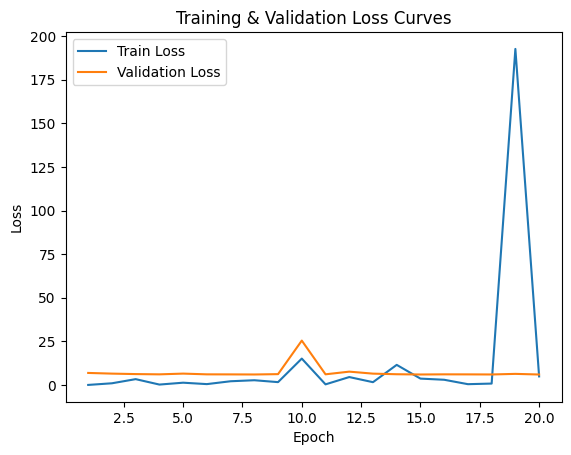


Neural Network Validation Performance:
MAE: 1.2828168771912514
RMSE: 2.4520058907783646
R²: 0.5899568237320837


In [7]:
# Part 2.3: Neural Network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure numeric features only
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_val_numeric = X_val.select_dtypes(include=[np.number])

# Sample 200000 rows for debug mode
X_train_sample = X_train_numeric.sample(200000, random_state=42)
y_regression_train_sample = y_regression_train.loc[X_train_sample.index]

# Convert to tensors
X_train_tensor = torch.tensor(X_train_sample.values, dtype=torch.float32)
y_regression_train_tensor = torch.tensor(y_regression_train_sample.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_numeric.values, dtype=torch.float32)
y_regression_val_tensor = torch.tensor(y_regression_val.values, dtype=torch.float32).view(-1, 1)

# Dataset + loader
train_dataset = TensorDataset(X_train_tensor, y_regression_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Define NN
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model = SimpleNN(X_train_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train
train_losses, val_losses = [], []
for epoch in range(20):  # 20 epochs as required
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    train_losses.append(loss.item())

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_regression_val_tensor).item()
        val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

plt.plot(range(1, 21), train_losses, label='Train Loss')
plt.plot(range(1, 21), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Curves')
plt.show()

model.eval()
with torch.no_grad():
    val_preds = model(X_val_tensor).numpy().flatten()

nn_mae = mean_absolute_error(y_regression_val, val_preds)
nn_rmse = np.sqrt(mean_squared_error(y_regression_val, val_preds))
nn_r2 = r2_score(y_regression_val, val_preds)

print("\nNeural Network Validation Performance:")
print("MAE:", nn_mae)
print("RMSE:", nn_rmse)
print("R²:", nn_r2)


### Neural Network vs Models

The neural network achieved MAE = 1.28, RMSE  2.45, and R² = 0.59 on the validation set.  
Compared to the baseline Linear Regression which MAE = 1.41, RMSE  2.60 and R² = 0.54 and Random Forest Regressor, MAE = 1.34, RMSE  2.61 and R² = 0.53.
Therefore since the RSME and MAE are smaller and the R² is closer to one, the the neural network shows a slight improvement in acheiving a better fit and reducing errors than the model


Part 3: Model Evaluation & Interpretation


Regression Models - Test Set Comparison:
                     Model       MAE      RMSE        R²
0        Linear Regression  1.418830  2.660832  0.529431
1  Random Forest Regressor  1.345933  2.656670  0.530901
2       Tuned RF Regressor  1.275461  2.536112  0.572510
3           Neural Network  1.279534  2.517247  0.578847

Classification Models - Test Set Comparison:
                       Model  Accuracy  Precision    Recall        F1  \
0        Logistic Regression  0.764576   0.765491  0.994679  0.865164   
1   Random Forest Classifier  0.710496   0.773593  0.874750  0.821066   
2  Tuned Logistic Regression  0.764599   0.765357  0.995049  0.865219   

    AUC-ROC  
0  0.593248  
1  0.558717  
2  0.593238  


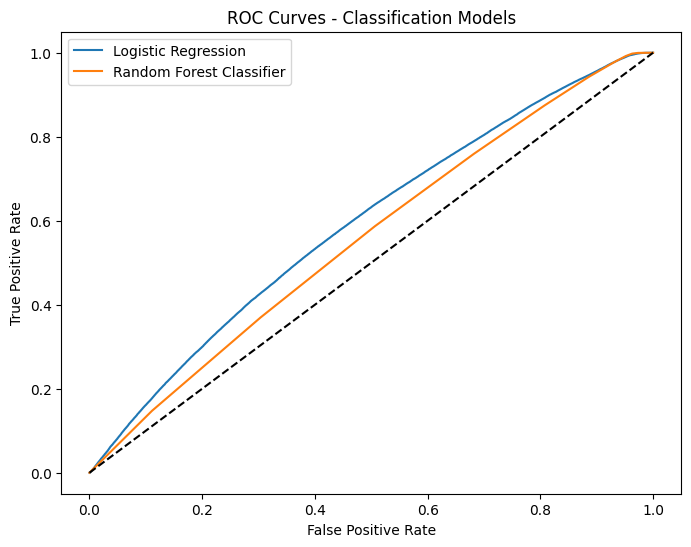

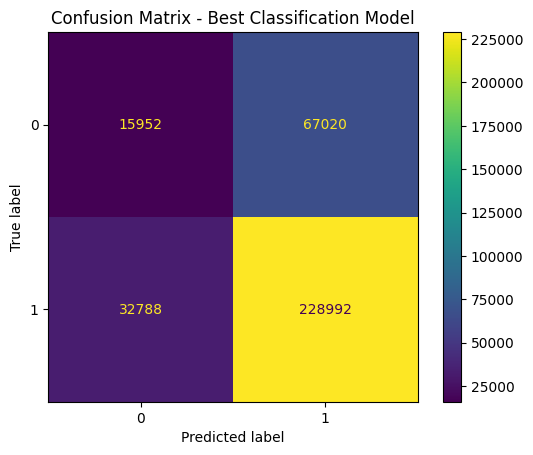

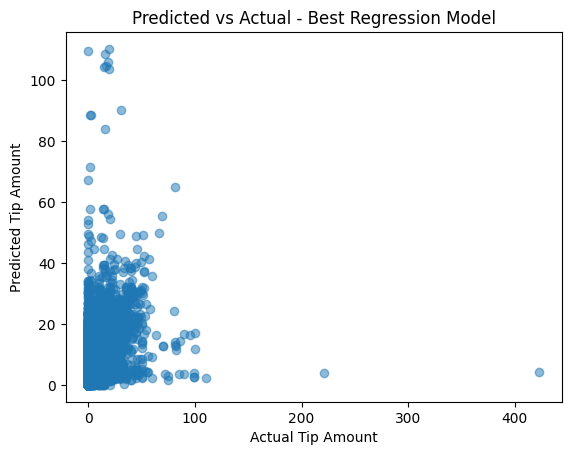

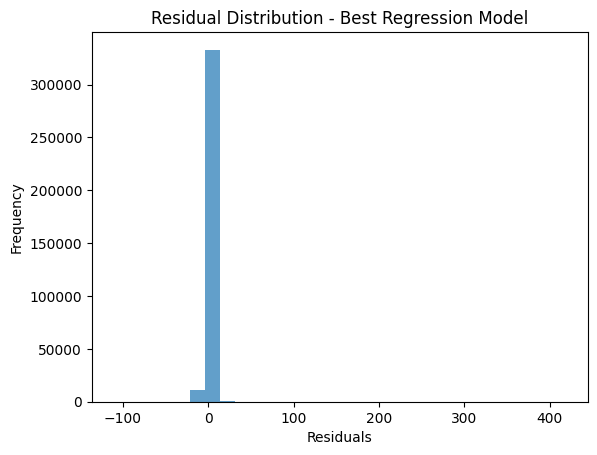

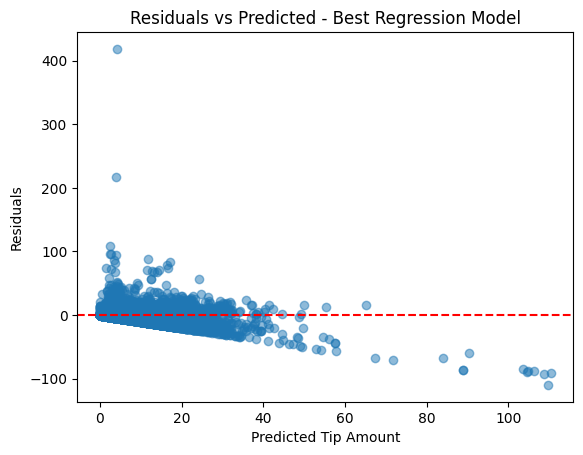

In [8]:
# Part 3.1: Comprehensive Evaluation
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

# Evaluate regression models on test set
regression_results_test = {
    "Model": ["Linear Regression", "Random Forest Regressor", "Tuned RF Regressor", "Neural Network"],
    "MAE": [
        mean_absolute_error(y_regression_test, lin_reg.predict(X_test)),
        mean_absolute_error(y_regression_test, rf_reg.predict(X_test)),
        mean_absolute_error(y_regression_test, grid_reg.best_estimator_.predict(X_test)) if 'grid_reg' in globals() else None,
        mean_absolute_error(y_regression_test, model(torch.tensor(X_test.select_dtypes(include=[np.number]).values, dtype=torch.float32)).detach().numpy().flatten())],
    "RMSE": [
        np.sqrt(mean_squared_error(y_regression_test, lin_reg.predict(X_test))),
        np.sqrt(mean_squared_error(y_regression_test, rf_reg.predict(X_test))),
        np.sqrt(mean_squared_error(y_regression_test, grid_reg.best_estimator_.predict(X_test))) if 'grid_reg' in globals() else None,
        np.sqrt(mean_squared_error(y_regression_test, model(torch.tensor(X_test.select_dtypes(include=[np.number]).values, dtype=torch.float32)).detach().numpy().flatten()))],
    "R²": [
        r2_score(y_regression_test, lin_reg.predict(X_test)),
        r2_score(y_regression_test, rf_reg.predict(X_test)),
        r2_score(y_regression_test, grid_reg.best_estimator_.predict(X_test)) if 'grid_reg' in globals() else None,
        r2_score(y_regression_test, model(torch.tensor(X_test.select_dtypes(include=[np.number]).values, dtype=torch.float32)).detach().numpy().flatten())]}
regression_df_test = pd.DataFrame(regression_results_test)
print("\nRegression Models - Test Set Comparison:")
print(regression_df_test)

# Evaluate classification models on test set
classification_results_test = {
    "Model": ["Logistic Regression", "Random Forest Classifier", "Tuned Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_classification_test, log_clf.predict(X_test)),
        accuracy_score(y_classification_test, rf_clf.predict(X_test)),
        accuracy_score(y_classification_test, grid_clf.best_estimator_.predict(X_test)) if 'grid_clf' in globals() else None],
    "Precision": [
        precision_score(y_classification_test, log_clf.predict(X_test)),
        precision_score(y_classification_test, rf_clf.predict(X_test)),
        precision_score(y_classification_test, grid_clf.best_estimator_.predict(X_test)) if 'grid_clf' in globals() else None],
    "Recall": [
        recall_score(y_classification_test, log_clf.predict(X_test)),
        recall_score(y_classification_test, rf_clf.predict(X_test)),
        recall_score(y_classification_test, grid_clf.best_estimator_.predict(X_test)) if 'grid_clf' in globals() else None],
    "F1": [
        f1_score(y_classification_test, log_clf.predict(X_test)),
        f1_score(y_classification_test, rf_clf.predict(X_test)),
        f1_score(y_classification_test, grid_clf.best_estimator_.predict(X_test)) if 'grid_clf' in globals() else None],
    "AUC-ROC": [
        roc_auc_score(y_classification_test, log_clf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_classification_test, rf_clf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_classification_test, grid_clf.best_estimator_.predict_proba(X_test)[:,1]) if 'grid_clf' in globals() else None]}
classification_df_test = pd.DataFrame(classification_results_test)
print("\nClassification Models - Test Set Comparison:")
print(classification_df_test)

# ROC curves
plt.figure(figsize=(8,6))
for name, model in [("Logistic Regression", log_clf), ("Random Forest Classifier", rf_clf)]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_classification_test, y_prob)
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Classification Models")
plt.legend()
plt.show()

# Confusion matrix for best classification model (example: RF Classifier)
best_clf = rf_clf
cm = confusion_matrix(y_classification_test, best_clf.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Best Classification Model")
plt.show()

# Scatter plot for best regression model (example: RF Regressor)
best_reg = rf_reg
y_pred_best = best_reg.predict(X_test)
plt.scatter(y_regression_test, y_pred_best, alpha=0.5)
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual - Best Regression Model")
plt.show()

# Residual analysis
residuals = y_regression_test - y_pred_best
plt.hist(residuals, bins=30, alpha=0.7)
plt.title("Residual Distribution - Best Regression Model")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Tip Amount")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted - Best Regression Model")
plt.show()


Model Evaluation Summary

Regression (Best Model):  
From the histogram, the errors are tightly centered around zero, showing most predictions are close to the actual tip amounts.
The residuals vs predicted scatter plot shows low variance for smaller predicted tips, but a wider spread and some outliers for larger tips.
Together, these plots suggest the regression model works well for typical trips but struggles more with extreme tip values.

Classification (Test Set Comparison):  
The confusion matrix shows the Logistic Regression had high recall of 0.99, meaning it correctly identifies nearly all high tip cases. However, the ROC curve shows an AUC of only 0.59, which indicates limited ability to separate positives from negatives cleanly.
The Random Forest Classifier baseline had lower accuracy and AUC than Logistic Regression, though its precision was slightly higher. This means it had less false alarms but missed some true positives.
The tuned Logistic Regression produced nearly identical results to the baseline, with only minor improvements in recall and F1.

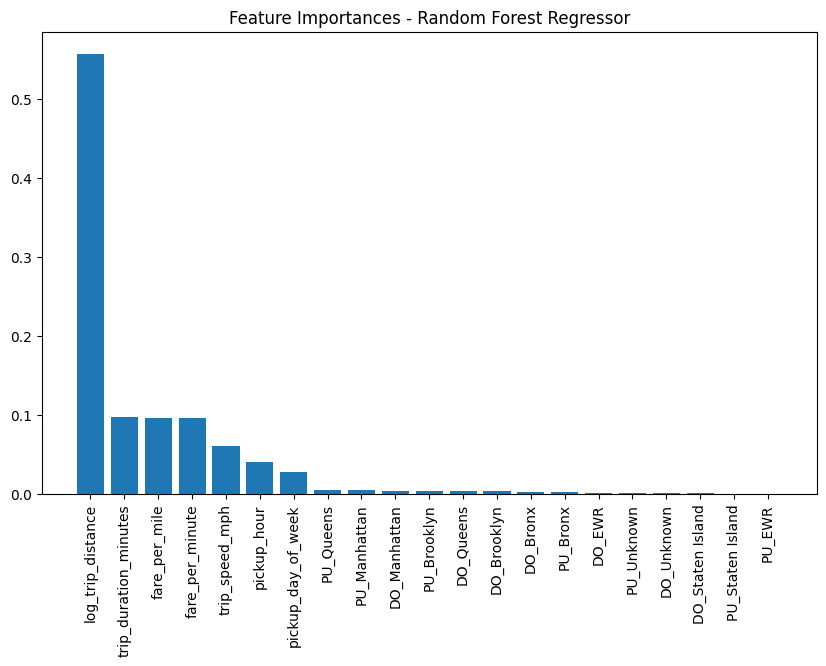


Linear Regression Coefficients:
                  Feature  Coefficient
16                 DO_EWR     4.171227
4       log_trip_distance     2.231903
19       DO_Staten Island     1.530879
11              PU_Queens     1.140166
5           fare_per_mile     0.173498
6         fare_per_minute     0.157883
0             pickup_hour     0.085365
2   trip_duration_minutes     0.024955
3          trip_speed_mph    -0.030649
1      pickup_day_of_week    -0.056826
13             PU_Unknown    -0.880358
10           PU_Manhattan    -1.078110
18              DO_Queens    -3.559179
9                  PU_EWR    -3.715866
17           DO_Manhattan    -3.989358
20             DO_Unknown    -4.013767
12       PU_Staten Island    -4.080551
15            DO_Brooklyn    -4.354321
8             PU_Brooklyn    -5.158176
14               DO_Bronx    -6.160232
7                PU_Bronx    -7.073398

Logistic Regression Coefficients:
                  Feature  Coefficient
11              PU_Queens     1.548

In [9]:
# Part 3.2: Feature Importance
# Random Forest feature importance
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.title("Feature Importances - Random Forest Regressor")
plt.show()

# Linear Regression coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lin_reg.coef_}).sort_values(by="Coefficient", ascending=False)
print("\nLinear Regression Coefficients:")
print(coef_df)

# Logistic Regression coefficients
log_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_clf.coef_[0]}).sort_values(by="Coefficient", ascending=False)
print("\nLogistic Regression Coefficients:")
print(log_coef_df)


## Written Analysis

a) Best Model Performance  
For regression, the Neural Network showed the strongest performance (MAE= 1.28, RMSE= 2.45, R²= 0.59), compared to the Linear Regression (R²= 0.54) and Random Forest Regressor (R²= 0.53) though the difference was small. This suggests the NN captured non-linear relationships in the data more effectively.  
For classification, Logistic Regression outperformed the Random Forest Classifier, with high recall(0.99) and accuracy(0.76). The tuned Logistic Regression had improvements but remained similar to the baseline. Logistic Regression was therefore the best classifier, particularly for identifying high tip cases.

b) Most Predictive Features  
Regression coefficients show that log_trip_distance, fare_per_mile, and fare_per_minute had strong positive predictors of tip amount, while pickup/dropoff boroughs had negative coefficients.  
Logistic Regression coefficients show that pickup/dropoff locations increase the likelihood of a high_tip, while Bronx pickups strongly reduce it.  
These results align with the intuition that longer trips and higher fares tend to yield larger tips, but different location contribute to variations.

c) Model Limitations  
Data leakage concerns: Derived features from fare and distance are already highly correalated to tip amount so the model is learning from features that are already close to the expected outcome.  
Feature limitations:
The dataset lacks details such as weather, traffic hours, rider general data like age or gender that could influence tipping.  
Biases: The dataset is skewed toward typical short trips with low tips, making it harder for models to generalize to rare high tip cases.

d)Potential Improvements  
Collect more diverse features like rider profiles, driver history, times or trip conditions and apply more advanced sampling or class-balancing techniques to better represent rare high tip cases.   
Been able to use the full dataset for hyperparameter tuning to observe the full benefit of  neural network training.

e) Neural Network vs Traditional ML  
The neural network slightly outperformed traditional models in regression, showing its ability to capture non-linear relationships. However, the improvement was minor, and training was less stable since the model was sensitive to the outliers.  
For classification, traditional Logistic Regression was superior, offering simpler results with strong recall but with weaker discrimination power.

Overall, while the NN demonstrated potential, traditional ML models were more reliable for this dataset, making them preferable for real world use.


AI Usage: Copilot used to generate code for unfamilair syntax, for debugging/ correcting code, interpreting output when different sized datasets were used, understanding approach needed to solve problem and Colab autopilot used for autocompleting code